# TASK 2

## 1. Introduction

Loan default prediction helps financial institutions minimize risk by identifying 
applicants who are likely to default on a loan.

In this project, we:
- Perform data cleaning and preprocessing
- Conduct exploratory data analysis (EDA)
- Train a classification model
- Evaluate model performance using accuracy and confusion matrix


In [1]:
# 2. Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")

In [2]:
# 3. Load the Dataset
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Display shape
print("Dataset shape:", train_df.shape)

# Display first 10 rows
train_df.head(10)

Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [3]:
# Display first 10 rows
test_df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban
6,LP001055,Female,No,1,Not Graduate,No,2226,0,59.0,360.0,1.0,Semiurban
7,LP001056,Male,Yes,2,Not Graduate,No,3881,0,147.0,360.0,0.0,Rural
8,LP001059,Male,Yes,2,Graduate,NaN,13633,0,280.0,240.0,1.0,Urban
9,LP001067,Male,No,0,Not Graduate,No,2400,2400,123.0,360.0,1.0,Semiurban


In [4]:
train_df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [7]:
train_df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## 4. Data Cleaning and Preprocessing

In [8]:
# Fill categorical missing values with mode
categorical_cols = train_df.select_dtypes(include='object').columns

for col in categorical_cols:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)
    if col in test_df.columns:
        test_df[col].fillna(train_df[col].mode()[0], inplace=True)

# Fill numerical missing values with median
num_cols = train_df.select_dtypes(include=np.number).columns

for col in num_cols:
    train_df[col].fillna(train_df[col].median(), inplace=True)
    if col in test_df.columns:
        test_df[col].fillna(train_df[col].median(), inplace=True)

train_df.isnull().sum()


C:\Users\DELL\AppData\Local\Temp\ipykernel_10100\3988811619.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mode()[0], inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10100\3988811619.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [9]:
train_df.drop("Loan_ID", axis=1, inplace=True)
test_ids = test_df["Loan_ID"]   # Keep IDs for submission
test_df.drop("Loan_ID", axis=1, inplace=True)

In [32]:
# Create a dictionary to store a separate LabelEncoder for each column
label_encoders = {}

# Fit and transform the training data
for col in train_df.select_dtypes(include='object').columns:
    # Create a new LabelEncoder for each column
    label_encoders[col] = LabelEncoder()
    # Fit and transform on training data
    train_df[col] = label_encoders[col].fit_transform(train_df[col])

# Transform the test data using the fitted encoders
for col in test_df.select_dtypes(include='object').columns:
    if col in label_encoders:
        # Handle unseen labels by replacing them with a placeholder
        # Get all unique values in the test column
        test_unique = test_df[col].unique()
        # Find values in test that weren't in train
        unseen_values = [val for val in test_unique if val not in label_encoders[col].classes_]
        
        if unseen_values:
            # Replace unseen values with the most common value from training
            most_common = train_df[col].mode()[0]
            for val in unseen_values:
                test_df.loc[test_df[col] == val, col] = most_common
                
            # Now transform
            test_df[col] = label_encoders[col].transform(test_df[col])
        else:
            # If column wasn't in training data, handle appropriately
            print(f"Column {col} not found in training data")

train_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## 5. Exploratory Data Analysis

Gender
1    502
0    112
Name: count, dtype: int64


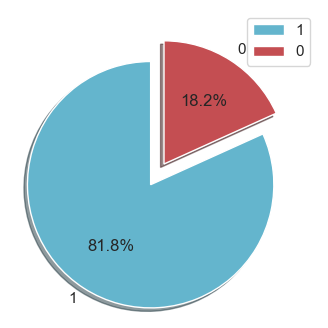

In [11]:
x=train_df["Gender"].value_counts()
print(x)
plt.figure(figsize=(6,4))
plt.pie(x.values,labels = x.index, startangle = 90,explode =[0.2,0],shadow=True,colors=["c","r"],autopct='%1.1f%%')
plt.legend()
plt.show()

Married
1    401
0    213
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_10100\3017996922.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


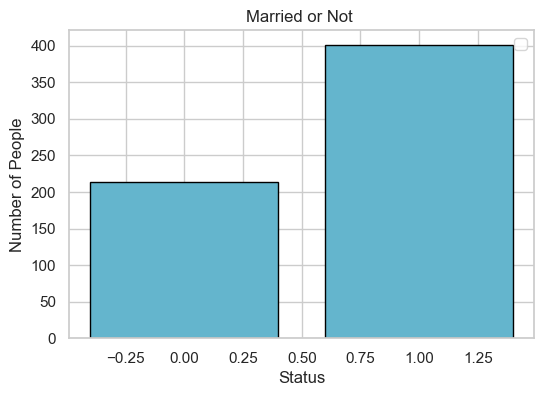

In [12]:
y=train_df["Married"].value_counts()
print(y)

plt.figure(figsize=(6,4))
plt.bar(y.index,y.values,color="c", edgecolor="black")
plt.title("Married or Not ")
plt.xlabel("Status")
plt.ylabel("Number of People")
plt.legend()
plt.show()

Dependents
0    360
1    102
2    101
3     51
Name: count, dtype: int64


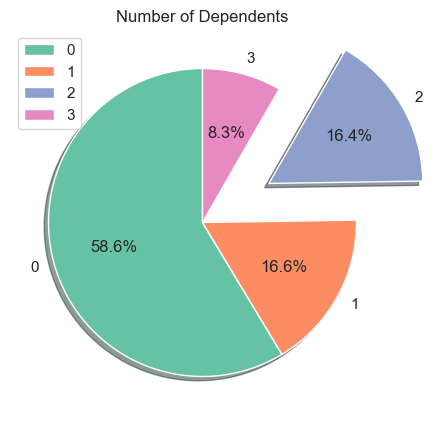

In [13]:
x=train_df["Dependents"].value_counts()
print(x)

colors = plt.cm.Set2.colors  
plt.figure(figsize=(6,5))
plt.pie(x.values,labels = x.index, startangle = 90,explode =[0,0,0.5,0],shadow=True,colors=colors,autopct='%1.1f%%')
plt.legend()
plt.title("Number of Dependents")
plt.show()

Education
0    480
1    134
Name: count, dtype: int64


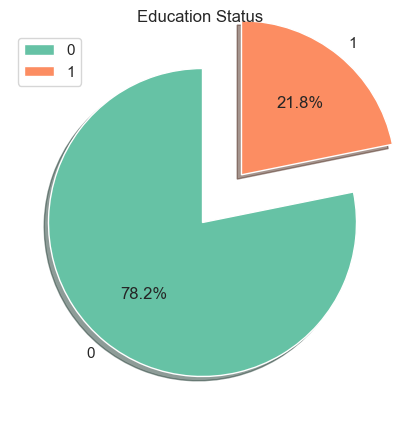

In [14]:
x=train_df["Education"].value_counts()
print(x)

plt.figure(figsize=(6,5))
plt.pie(x.values,labels = x.index, startangle = 90,explode =[0,0.4],shadow=True,colors=colors,autopct='%1.1f%%')
plt.legend()
plt.title("Education Status ")
plt.show()


Property_Area
1    233
2    202
0    179
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_10100\3790687493.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


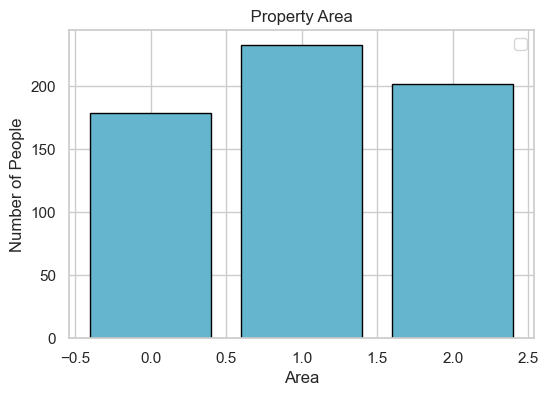

In [15]:
y=train_df["Property_Area"].value_counts()
print(y)

plt.figure(figsize=(6,4))
plt.bar(y.index,y.values,color="c", edgecolor="black")
plt.title(" Property Area ")
plt.xlabel("Area")
plt.ylabel("Number of People")
plt.legend()
plt.show()

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_numeric_column(df, column):
    print(f"📊 Analysis for: {column}")
    print("-"*50)
    
    print(df[column].describe())
    print(f"Median : {df[column].median()}")
    print(f"Mode   : {df[column].mode()[0]}")
    print(f"Std    : {df[column].std()}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    
    sns.histplot(df[column], kde=True, bins=50, ax=axes[0])
    axes[0].set_title(f"Distribution of {column}")
    

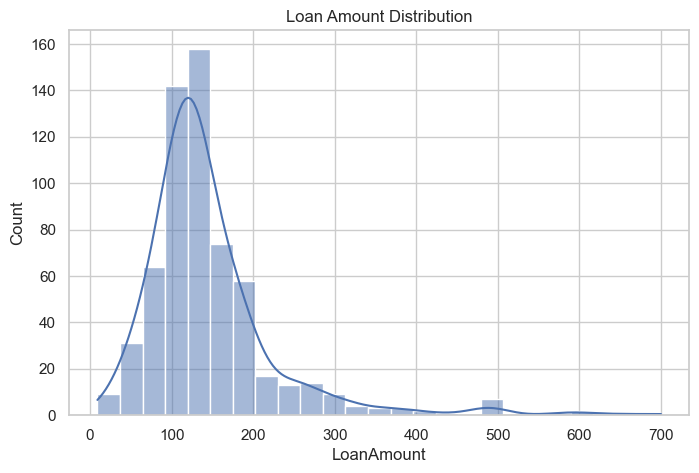

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["LoanAmount"], bins=25, kde=True)
plt.title("Loan Amount Distribution")
plt.show()


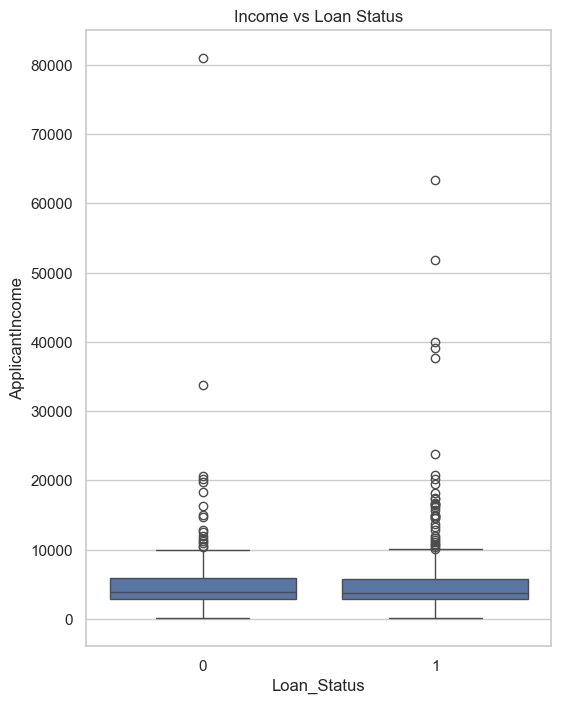

In [18]:
plt.figure(figsize=(6,8))
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=train_df)
plt.title("Income vs Loan Status")
plt.show()

## 6. Train Validation and Model Training

In [19]:
X = train_df.drop("Loan_Status", axis=1)
y = train_df["Loan_Status"]

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale only numeric columns
num_cols = X_train.select_dtypes(include=np.number).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])


In [22]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_val_pred = log_reg.predict(X_val)


## 7. Model Evaluation


In [23]:
val_accuracy = accuracy_score(y_val, y_val_pred)
print("Validation Accuracy:", val_accuracy)


Validation Accuracy: 0.7886178861788617


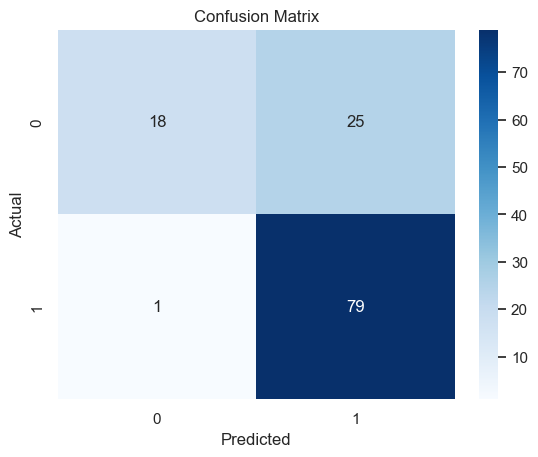

In [24]:
cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [25]:
print("Classification Report\n\n", classification_report(y_val, y_val_pred))

Classification Report

               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



**Validation Results Analysis:**

- Overall accuracy: 79%
- The model predicts approved loans very well (recall 0.99 for class 1)
- It struggles to correctly identify non-approved loans (recall 0.42 for class 0)
- This indicates a slight bias toward the majority class.


In [26]:
# Encode test dataset using SAME mappings as training
for col in test_df.select_dtypes(include='object').columns:
    if col in label_encoders:
        test_df[col] = label_encoders[col].transform(test_df[col])


In [27]:
test_df[num_cols] = scaler.transform(test_df[num_cols])


## 8. Generating Predictions for Test Set


In [28]:
print(test_df.select_dtypes(include='object').columns)

Index([], dtype='object')


In [29]:
np.unique(log_reg.predict(test_df), return_counts=True)

(array([0, 1]), array([ 59, 308]))

In [30]:
# Make predictions
test_predictions = log_reg.predict(test_df)

# Convert 0/1 back to N/Y
test_predictions = ["Y" if pred == 1 else "N" for pred in test_predictions]
print(test_predictions[:50])


['Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y']


### Predictions

**Y = Loan Approved**

**N = Loan Rejected**

## 9. Create Submission File


In [31]:

# Create submission file
submission = pd.DataFrame({
    "Loan_ID": test_ids,
    "Loan_Status": test_predictions
})

submission.to_csv("submission.csv", index=False)

print("Submission file created successfully")


Submission file created successfully


## 10. Conclusion

We built a Logistic Regression model to predict loan default using the provided train and test datasets. 
The model achieved a validation accuracy of around 79%. After training, we generated predictions for the test dataset and saved them to a CSV file.

### Key Learning Points:
- Handled missing values consistently across train and test
- Categorical encoding
- Model training and evaluation
- Prediction file creation for submission


## 10. Conclusion

In this project, we performed exploratory data analysis, preprocessing, and predictive modeling on the Loan Prediction dataset using the provided train and test files.

After handling missing values and encoding categorical variables, we trained a Logistic Regression model to predict loan approval status. The model achieved a validation accuracy of approximately **79%**.

Based on the classification report:

- The model performs very well in predicting approved loans (high recall for class 1).
- It struggles to correctly identify rejected loan applications (lower recall for class 0).
- This indicates a slight bias toward the majority class (approved loans).

While the overall accuracy is reasonably strong, the lower recall for rejected applications suggests that some potentially high-risk applicants may not be correctly identified. Despite this limitation, the model provides a solid baseline performance and demonstrates that features such as applicant income, loan amount, credit history, and property area contribute significantly to loan approval prediction.

After evaluation, predictions were generated for the test dataset and saved as a CSV file for submission.

### Key Learning Points: ###
- Consistent handling of missing values across training and test datasets  
- Proper categorical encoding without data leakage  
- Model training and evaluation using classification metrics  
- Interpretation of results beyond overall accuracy  
- Creation of a prediction file for final submission  


## Future Improvements

Several enhancements can be made to improve model performance:

1. **Handle Class Imbalance**
   - Use `class_weight='balanced'`
   - Apply resampling techniques such as SMOTE

2. **Feature Engineering**
   - Create income-to-loan ratio features
   - Combine applicant and co-applicant income
   - Explore interaction features

3. **Try Advanced Models**
   - Random Forest
   - Gradient Boosting
   - XGBoost
   - Support Vector Machines

4. **Hyperparameter Tuning**
   - Use GridSearchCV or RandomizedSearchCV
   - Optimize regularization strength (C)

5. **Cross-Validation**
   - Apply k-fold cross-validation for more robust performance evaluation

With these improvements, the model could achieve better balance between precision and recall while maintaining strong predictive accuracy.
